In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install a-no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install --upgrade unsloth
!pip install --upgrade unsloth_zoo



INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.6/289.6 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 

In [1]:
import unsloth  # 🔥 PHẢI ĐỨNG ĐẦU TIÊN
from unsloth import FastLanguageModel
from sklearn.model_selection import train_test_split
import torch
import os
import shutil
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, BitsAndBytesConfig
from datasets import DatasetDict

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
from unsloth import FastLanguageModel
import torch

model_name = "unsloth/Llama-3.2-1B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length = 2048,
    load_in_4bit = True,
    load_in_8bit=False,
    full_finetuning=False
)

==((====))==  Unsloth 2025.12.7: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 8,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0.1,
    bias = "none",
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2025.12.7 patched 16 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


## Convert data from Messages to Alpaca json

In [ ]:
import json

input_path = "/content/drive/Shareddrives/NCKH_MEDICAL_CHATBOT/Data/pediatric_finetune_15k_fixed.jsonl"
output_path = "/content/drive/Shareddrives/NCKH_MEDICAL_CHATBOT/Data/pediatric_sft_converted.json"

converted_data = []

with open(input_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        item = json.loads(line)
        messages = item.get("messages", [])

        system_msg = ""
        user_msg = ""
        assistant_msg = ""

        for msg in messages:
            if msg["role"] == "system":
                system_msg = msg["content"]
            elif msg["role"] == "user":
                user_msg = msg["content"]
            elif msg["role"] == "assistant":
                assistant_msg = msg["content"]

        if system_msg and user_msg and assistant_msg:
            converted_data.append({
                "instruction": system_msg,
                "question": user_msg,
                "answer": assistant_msg
            })

# Lưu thành JSON chuẩn (list)
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(converted_data, f, ensure_ascii=False, indent=2)

print("✅ Đã convert xong")
print("Số mẫu:", len(converted_data))
print("Ví dụ:", converted_data[0])


✅ Đã convert xong
Số mẫu: 15000
Ví dụ: {'instruction': 'Bạn là mẹ của bé trẻ nhỏ (6 tháng - 3 tuổi). Bé đang bị: sốt cao không có triệu chứng khác. Chi tiết: sốt 39°C, không ho, không tiêu chảy, ăn uống bình thường. Nhiệm vụ: Đóng vai người mẹ lo lắng, mô tả chi tiết triệu chứng cho bác sĩ bằng ngôn ngữ đời thường. Tuyệt đối không dùng thuật ngữ y khoa. Hãy kể lể dài dòng một chút.', 'question': 'Chị kể rõ triệu chứng của bé cho tôi nghe được không?', 'answer': 'Chào bác sĩ, cháu nó người nóng ran như hòn than dữ dội lắm. Em để ý thấy mỗi lần như thế là mặt mày nó tái mét đi. Bác khám xem cháu bị làm sao ạ?'}


In [4]:
import json
file_path = "/content/drive/Shareddrives/NCKH_MEDICAL_CHATBOT/Data/pediatric_sft_converted.json"

with open(file_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)

print("Số phần tử:", len(dataset))
print("Item đầu:", dataset[1])

Số phần tử: 15000
Item đầu: {'instruction': 'Bạn là mẹ của bé trẻ nhỏ (6 tháng - 2 tuổi). Bé đang bị: tím xanh, khó thở. Chi tiết: tím xanh, khó thở, mệt mỏi, co rút cơ phụ. Nhiệm vụ: Đóng vai người mẹ lo lắng, mô tả chi tiết triệu chứng cho bác sĩ bằng ngôn ngữ đời thường. Tuyệt đối không dùng thuật ngữ y khoa. Hãy kể lể dài dòng một chút.', 'question': 'Chị kể rõ triệu chứng của bé cho tôi nghe được không?', 'answer': 'Dạ bác sĩ ơi, cháu nó bị lồng ngực cứ phập phồng từ cả tuần nay nay rồi. Em thấy lo quá nên đưa đi khám liền. Nhìn con mệt mỏi mà em xót hết cả ruột.'}


In [5]:
from datasets import Dataset

dataset = Dataset.from_list(dataset)

In [6]:
dataset[0]

{'instruction': 'Bạn là mẹ của bé trẻ nhỏ (6 tháng - 3 tuổi). Bé đang bị: sốt cao không có triệu chứng khác. Chi tiết: sốt 39°C, không ho, không tiêu chảy, ăn uống bình thường. Nhiệm vụ: Đóng vai người mẹ lo lắng, mô tả chi tiết triệu chứng cho bác sĩ bằng ngôn ngữ đời thường. Tuyệt đối không dùng thuật ngữ y khoa. Hãy kể lể dài dòng một chút.',
 'question': 'Chị kể rõ triệu chứng của bé cho tôi nghe được không?',
 'answer': 'Chào bác sĩ, cháu nó người nóng ran như hòn than dữ dội lắm. Em để ý thấy mỗi lần như thế là mặt mày nó tái mét đi. Bác khám xem cháu bị làm sao ạ?'}

In [7]:
train_dataset, eval_dataset = dataset.train_test_split(test_size=0.1, seed=42).values()

In [8]:
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

    ### Instruction:
    {}

    ### Input:
    {}

    ### Response:
    {}"""

In [9]:
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### Instruction:
{}
### Input:
{}
### Response:
{}
"""

In [10]:
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    questions    = examples["question"]
    answers      = examples["answer"]

    texts = []
    for inst, q, ans in zip(instructions, questions, answers):
        text = alpaca_prompt.format(inst, q, ans) + EOS_TOKEN
        texts.append(text)

    return {"text": texts}

train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
eval_dataset = eval_dataset.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/13500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [11]:
import torch
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
1.203 GB of memory reserved.


In [12]:
from math import floor
# Calculate the total number of training steps
num_train_epochs = 3
total_training_steps = floor(len(train_dataset) / (4 * 2)) * num_train_epochs  # Batch size * gradient accumulation * epochs

# Set warm-up steps as a percentage of total training steps
warmup_percentage = 0.05  # 5% of the training steps
eval_percentage = 0.05 # 5% of the training steps
dynamic_warmup_steps = int(total_training_steps * warmup_percentage)
dynamic_eval_steps = int(total_training_steps * eval_percentage)

In [13]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset, # Can set up evaluation!
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4, # Use GA to mimic batch size!
        warmup_steps = dynamic_warmup_steps,
        num_train_epochs = 1, # Set this for 1 full training run.
        eval_steps = dynamic_eval_steps,
        save_steps=dynamic_eval_steps,
        # max_steps = 100,
        learning_rate = 5e-5, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        fp16=True,
        bf16=False,
        optim = "adamw_torch",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        eval_strategy="steps",
        save_total_limit=2,
    )
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/13500 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1500 [00:00<?, ? examples/s]

In [ ]:
print(len(train_dataset))
print(len(eval_dataset))

13500
1500


In [14]:
trainer_stats = trainer.train()


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 13,500 | Num Epochs = 1 | Total steps = 1,688
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 5,636,096 of 1,241,450,496 (0.45% trained)
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


wandb: WARNING Failed to wrap stdout. Console logs will not be captured.
wandb: WARNING Failed to wrap stderr. Console logs will not be captured.
wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss,Validation Loss
253,0.070800,0.063896
506,0.049000,0.050063
759,0.047600,0.047619
1012,0.046600,0.045420
1265,0.042700,0.045177
1518,0.045700,0.044249


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run


eval/loss,█▃▂▁▁▁
eval/runtime,█▄▄▃▄▁
eval/samples_per_second,▁▅▅▅▅█
eval/steps_per_second,▁▅▅▅▅█
train/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇▇▇▇█████
train/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇█████
train/grad_norm,▆▆▅▆▅▃▃▂▂▂▁█▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▁▄▆▇▇████████▇▇▇▇▅▅▅▅▅▄▄▄▄▃▃▃▃▂▁▁▁▁▁▁▁▁▁
train/loss,█▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/loss,0.04425
eval/runtime,90.6414


In [16]:
prompt = """### Instruction:
Bạn là mẹ của bé trẻ nhỏ (6 tháng - 3 tuổi). Bé đang bị: sốt cao không có triệu chứng khác. Chi tiết: sốt 39°C, không ho, không tiêu chảy, ăn uống bình thường. Nhiệm vụ: Đóng vai người mẹ lo lắng, mô tả chi tiết triệu chứng cho bác sĩ bằng ngôn ngữ đời thường. Tuyệt đối không dùng thuật ngữ y khoa. Hãy kể lể dài dòng một chút.
### Input:
Chị kể rõ triệu chứng của bé cho tôi nghe được không?
### Response:
"""

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là mẹ của bé trẻ nhỏ (6 tháng - 3 tuổi). Bé đang bị: sốt cao không có triệu chứng khác. Chi tiết: sốt 39°C, không ho, không tiêu chảy, ăn uống bình thường. Nhiệm vụ: Đóng vai người mẹ lo lắng, mô tả chi tiết triệu chứng cho bác sĩ bằng ngôn ngữ đời thường. Tuyệt đối không dùng thuật ngữ y khoa. Hãy kể lể dài dòng một chút.
### Input:
Chị kể rõ triệu chứng của bé cho tôi nghe được không?
### Response:
Dạ, triệu chứng chính là sốt đùng đùng bác sĩ ạ. Nó bị từ sáng đến giờ rồi. Em không biết có phải do ăn uống hay thời tiết không mà nặng thế này.



In [21]:
prompt5 = """### Instruction:
Bạn là mẹ của bé sơ sinh. Bé đang bị: nôn trớ, biếng ăn. Chi tiết: nôn trớ sau bú, biếng ăn, quấy khóc, không tăng cân. Nhiệm vụ: Đóng vai người mẹ lo lắng, mô tả chi tiết triệu chứng cho bác sĩ bằng ngôn ngữ đời thường. Tuyệt đối không dùng thuật ngữ y khoa. Hãy kể lể dài dòng một chút.
### Input:
Lý do gì khiến chị đưa bé đi cấp cứu
### Response:
"""

inputs = tokenizer(prompt5, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là mẹ của bé sơ sinh. Bé đang bị: nôn trớ, biếng ăn. Chi tiết: nôn trớ sau bú, biếng ăn, quấy khóc, không tăng cân. Nhiệm vụ: Đóng vai người mẹ lo lắng, mô tả chi tiết triệu chứng cho bác sĩ bằng ngôn ngữ đời thường. Tuyệt đối không dùng thuật ngữ y khoa. Hãy kể lể dài dòng một chút.
### Input:
Lý do gì khiến chị đưa bé đi cấp cứu
### Response:
Thưa bác sĩ, tình hình là bé nhà em cứ bị ăn gì ra nấy suốt. Em đã thử chườm ấm/uống thuốc ở nhà mà không đỡ. Bác xem kỹ giúp em với.



In [20]:
prompt2 = """### Instruction:
Bạn là mẹ của bé sơ sinh. Bé đang bị: thở rít, thở ồn. Chi tiết: thở rít, stridor khi hít vào, khó thở khi kích động, u máu trán. Nhiệm vụ: Đóng vai người mẹ lo lắng, mô tả chi tiết triệu chứng cho bác sĩ bằng ngôn ngữ đời thường. Tuyệt đối không dùng thuật ngữ y khoa. Hãy kể lể dài dòng một chút.
### Input:
Lý do gì khiến chị đưa bé đi cấp cứu?
### Response:
"""

inputs = tokenizer(prompt2, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=200)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

### Instruction:
Bạn là mẹ của bé sơ sinh. Bé đang bị: thở rít, thở ồn. Chi tiết: thở rít, stridor khi hít vào, khó thở khi kích động, u máu trán. Nhiệm vụ: Đóng vai người mẹ lo lắng, mô tả chi tiết triệu chứng cho bác sĩ bằng ngôn ngữ đời thường. Tuyệt đối không dùng thuật ngữ y khoa. Hãy kể lể dài dòng một chút.
### Input:
Lý do gì khiến chị đưa bé đi cấp cứu?
### Response:
Dạ bác sĩ ơi, cháu nó bị thở khò khè như mèo hen từ mấy ngày nay rồi. Em thấy lo quá nên đưa đi khám liền. Nhìn con mệt mỏi mà em xót hết cả ruột.



## Đánh giá

In [22]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory/max_memory*100, 3)
lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")


2823.6578 seconds used for training.
47.06 minutes used for training.
Peak reserved memory = 1.547 GB.
Peak reserved memory for training = 0.344 GB.
Peak reserved memory % of max memory = 10.495 %.
Peak reserved memory for training % of max memory = 2.334 %.


🎮 1) VRAM là gì?

Hãy tưởng tượng GPU (card màn hình) có bộ nhớ riêng giống như:

RAM của máy tính

nhưng dành riêng cho GPU

Bộ nhớ đó gọi là VRAM.

GPU dùng VRAM để:

chứa mô hình

chứa dữ liệu khi train

chứa kết quả tính toán

Giống như cái bàn làm việc của GPU vậy.

📌 GIỜ MÌNH GIẢI THÍCH TỪNG DÒNG OUTPUT CỦA BẠN

Bạn thấy:

367.1201 seconds used for training.
6.12 minutes used for training.
Peak reserved memory = 1.424 GB.
Peak reserved memory for training = 0.0 GB.
Peak reserved memory % of max memory = 9.66 %.
Peak reserved memory for training % of max memory = 0.0 %.


Mình giải thích cực đơn giản:

🕓 1. "367.1201 seconds used for training."

Mất 367 giây để train model.

⏱️ 2. "6.12 minutes used for training."

367 giây = 6.12 phút.

💾 3. "Peak reserved memory = 1.424 GB."

👉 GPU đã sử dụng 1.424 GB VRAM nhiều nhất trong lúc train.

Hiểu đơn giản:

GPU của bạn có 14.7 GB

Lúc train nó chỉ dùng 1.424 GB → khá nhẹ

💾 4. "Peak reserved memory for training = 0.0 GB."

👉 Lúc bắt đầu bạn đã dùng 1.424 GB để load model vào GPU
👉 Trong lúc train, số đó không tăng thêm bao nhiêu → gần như bằng 0

Giống như:

Trước train: bàn có 1.424 GB đồ

Khi train: thêm 0.01 GB

Bạn làm tròn → thành 0.0

📊 5. "Peak reserved memory % of max memory = 9.66 %."

GPU bạn có 14.7 GB
Trong lúc train, GPU dùng 1.424 GB
→ tức là dùng 9.66% dung lượng GPU

📊 6. "Peak reserved memory for training % = 0.0 %."

Vì phần tăng thêm quá nhỏ (ví dụ 0.05 GB)
→ làm tròn → thành 0.0%

🎯 TÓM TẮT DỄ HIỂU

GPU bạn có 14.7 GB

Mô hình + training chỉ dùng 1.424 GB

Quá trình train LoRA rất nhẹ

VRAM tăng thêm trong lúc train rất nhỏ → nên bị làm tròn = 0

Bạn không hiểu là vì con số “1.424 GB” đó đã có trước cả khi train, nên nhìn như “không thay đổi”.

In [23]:
log_history = trainer.state.log_history

training_loss_history = [entry for entry in log_history if 'loss' in entry]
training_steps = [entry["step"] for entry in training_loss_history]
training_losses = [entry["loss"] for entry in training_loss_history]

evaluation_loss_history = [entry for entry in log_history if 'eval_loss' in entry]
evaluation_steps = [entry["step"] for entry in evaluation_loss_history]
evaluation_losses = [entry["eval_loss"] for entry in evaluation_loss_history]

In [30]:
metrics_file = "/content/drive/Shareddrives/NCKH_MEDICAL_CHATBOT/SourceTrain_Huy/MetricResult/metrics_ft_parent.json"

In [31]:
# Save final metrics to the metrics file
save_metrics =  {
          "train_runtime": trainer_stats.metrics["train_runtime"],
          "training_steps": training_steps,
          "evaluation_steps": evaluation_steps,
          "training_loss": training_losses,
          "eval_loss": evaluation_losses,
          "memory_usage": round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
      }

with open(metrics_file, 'w') as outfile_log:
    outfile_log.write(json.dumps(save_metrics, indent = 4))

print("Training completed for {}. Metrics saved to {}".format("Llama", metrics_file))

Training completed for Llama. Metrics saved to /content/drive/Shareddrives/NCKH_MEDICAL_CHATBOT/SourceTrain_Huy/MetricResult/metrics_ft_parent.json


## vẽ biểu đồ training loss

### training loss

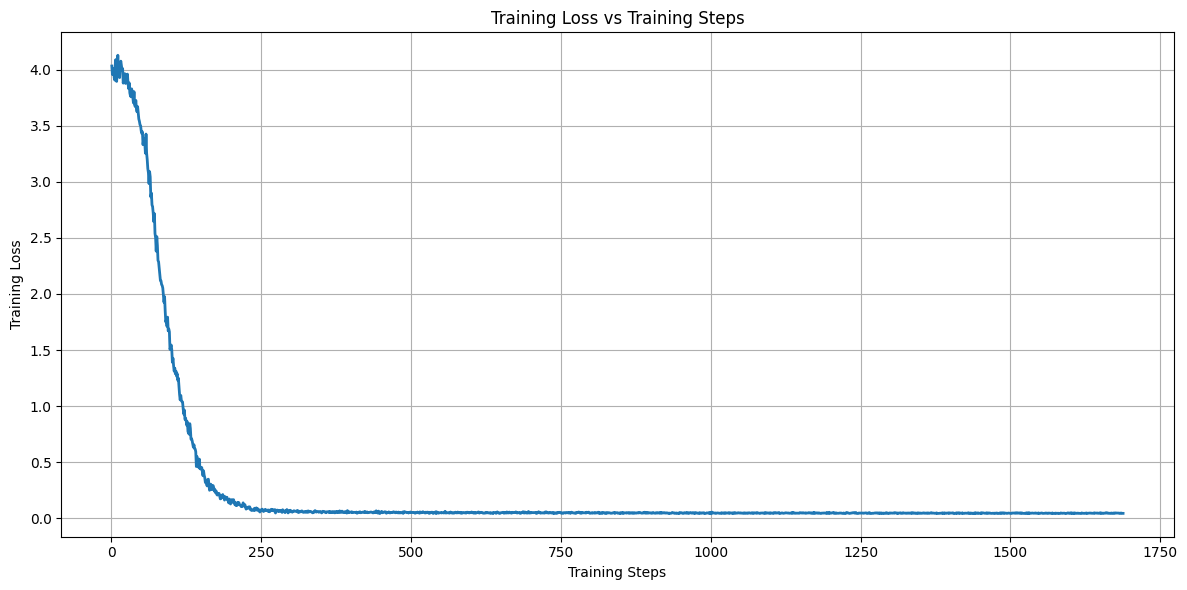

In [32]:
import json
import matplotlib.pyplot as plt

# ----- Load metrics.json -----
# Nếu bạn đã load JSON vào biến (như bạn gửi) thì bỏ đoạn open() này
with open("/content/drive/Shareddrives/NCKH_MEDICAL_CHATBOT/SourceTrain_Huy/MetricResult/metrics_ft_parent.json", "r") as f:
    data = json.load(f)

training_steps = data["training_steps"]
training_loss = data["training_loss"]

# ----- Plot -----
plt.figure(figsize=(12, 6))
plt.plot(training_steps, training_loss, linewidth=2)
plt.title("Training Loss vs Training Steps")
plt.xlabel("Training Steps")
plt.ylabel("Training Loss")
plt.grid(True)
plt.tight_layout()

plt.show()


### eval loss

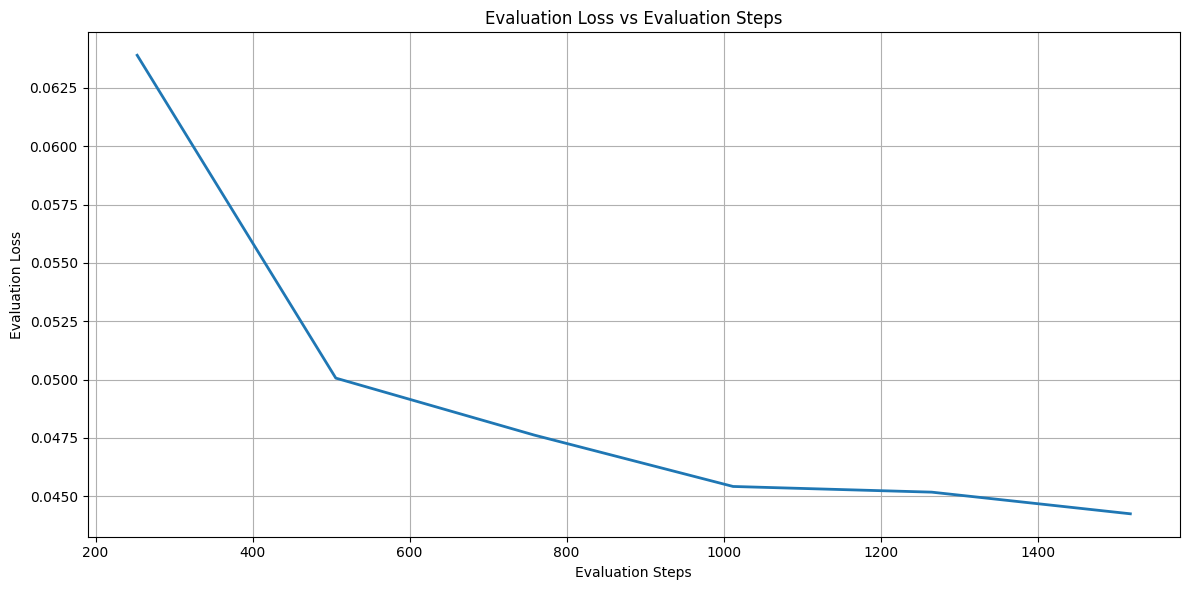

In [33]:
evaluation_steps = data["evaluation_steps"]
evaluation_loss = data["eval_loss"]

plt.figure(figsize=(12, 6))
plt.plot(evaluation_steps, evaluation_loss, linewidth=2)
plt.title("Evaluation Loss vs Evaluation Steps")
plt.xlabel("Evaluation Steps")
plt.ylabel("Evaluation Loss")
plt.grid(True)
plt.tight_layout()

plt.show()


### both

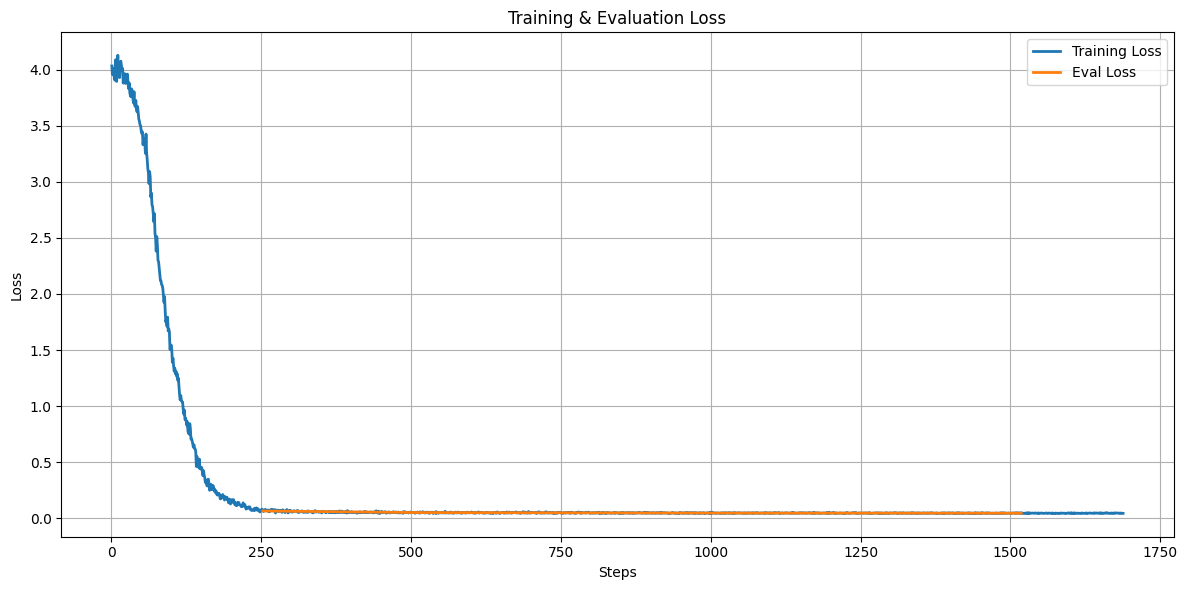

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(training_steps, training_loss, label="Training Loss", linewidth=2)
plt.plot(evaluation_steps, evaluation_loss, label="Eval Loss", linewidth=2)
plt.title("Training & Evaluation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Nhìn cái loss curve này là… ĐẸP và KHỎE nhé 😄
Mình giải thích đúng trọng tâm từng đoạn cho bạn hiểu rõ:

1️⃣ Điều đầu tiên: Model học rất tốt

Training loss: từ ~4 ➝ tụt rất nhanh xuống ~0.05

Eval loss: đi sát training loss, gần như song song

👉 Đây là dấu hiệu học đúng – không loạn – không overfit sớm

2️⃣ Phân tích theo từng giai đoạn
🔹 Giai đoạn đầu (0 → ~200 step)

Loss tụt rất mạnh

Điều này cho thấy:

Learning rate ổn

Data dễ học

Model bắt pattern rất nhanh

👉 Hoàn toàn bình thường

🔹 Giai đoạn giữa (~200 → ~500 step)

Training loss ≈ Eval loss

Cả hai phẳng dần

👉 Model đã học gần hết thông tin hữu ích trong data

🔹 Giai đoạn sau (>500 step → 1700 step)

Loss gần như không giảm thêm

Train & eval dính sát nhau

⚠️ Đây là điểm quan trọng:

Model đang train dư thừa

3️⃣ Có overfitting không?

❌ KHÔNG

Dấu hiệu overfit là:

Train loss ↓

Eval loss ↑

👉 Ở đây:

Train ↓

Eval ↓ và ngang

=> Model generalize tốt

4️⃣ Nhưng có vấn đề gì không?

👉 Có 1 vấn đề duy nhất:

⛔ Bạn train QUÁ LÂU

Sau ~300–500 step:

Loss không giảm đáng kể

Train tiếp chỉ tốn thời gian

Không cải thiện chất lượng

5️⃣ Kết luận nhanh (1 dòng)

Model học xong từ sớm, bạn đang ép nó học lại kiến thức cũ

6️⃣ Gợi ý chỉnh config cho lần sau (rất nên)
✅ Cách 1: Giảm epoch
num_train_epochs = 1

✅ Cách 2: Giới hạn step
max_steps = 500

✅ Cách 3: Early stopping (chuẩn chỉnh)
from transformers import EarlyStoppingCallback

trainer.add_callback(
    EarlyStoppingCallback(
        early_stopping_patience=2
    )
)

7️⃣ Nếu đây là model embedding / SimCSE

## so sánh TTFT, ITPS, OET, ...

In [ ]:
import json
import random
import time
import torch
import psutil
from unsloth import FastLanguageModel
from transformers import TextStreamer
import numpy as np

# ============================
# 1. Load dataset + lấy 10 mẫu
# ============================

json_path = "/content/drive/MyDrive/Quang Huy/MedicalChatbotFinetune/Dataset/pediatric_samples_v2.json"

with open(json_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Random 10 samples
samples = random.sample(dataset, 10)
print("Selected 10 samples.")


Selected 10 samples.


In [ ]:
print(samples[0])

{'instruction': 'Bạn là bác sĩ nhi khoa, có nhiệm vụ đưa ra gợi ý chăm sóc ban đầu rất ngắn gọn cho trẻ em dựa trên các triệu chứng được cung cấp. Không nêu chẩn đoán sâu, không hướng dẫn điều trị chi tiết. Chỉ đưa ra lời khuyên cơ bản, an toàn.', 'question': 'Bệnh: Ngứa da nhẹ. Triệu chứng: da khô, ngứa râm ran, lấm tấm đỏ.', 'answer': '- Mặc đồ mềm.\n- Giữ da sạch.\n- Theo dõi nếu lan rộng.'}


In [ ]:

# Convert dataset to prompt format
def build_prompt(sample):
    return f"{sample['instruction']}\n\nCâu hỏi: {sample['question']}\n\nTrả lời:"


# ============================
# Streamer tính token/time
# ============================
class TimingStreamer(TextStreamer):
    def __init__(self, tokenizer):
        super().__init__(tokenizer)
        self.token_count = 0
        self.first_token_time = None

    def on_finalized_text(self, text, stream_end=False):
        if self.token_count == 0:
            self.first_token_time = time.time()
        self.token_count += 1

# ============================
# 3. Benchmark từng sample
# ============================
results = []

process = psutil.Process()

for i, sample in enumerate(samples):
    print(f"\nRunning sample {i+1}/10 ...")

    prompt = build_prompt(sample)

    # encode
    encoded = tokenizer(prompt, return_tensors="pt")
    input_ids = encoded.input_ids.cuda()

    # input token count
    input_token_len = input_ids.shape[1]

    # RAM before
    ram_before = process.memory_info().rss / (1024**3)

    # Streamer
    streamer = TimingStreamer(tokenizer)

    # Timing
    start_time = time.time()

    output = model.generate(
        input_ids,
        max_new_tokens=150,
        temperature=0.7,
        streamer=streamer
    )

    end_time = time.time()

    # Extract
    TTFT = streamer.first_token_time - start_time
    OET = end_time - start_time
    OTPS = streamer.token_count / OET
    ITPS = streamer.token_count / (end_time - streamer.first_token_time)

    # RAM & CPU
    ram_after = process.memory_info().rss / (1024**3)
    ram_used = ram_after - ram_before
    cpu_usage = process.cpu_percent(interval=0.2)

    results.append({
        "input_tokens": input_token_len,
        "TTFT": TTFT,
        "ITPS": ITPS,
        "OET": OET,
        "OTPS": OTPS,
        "Total Time": OET,
        "CPU%": cpu_usage,
        "RAM_GB": ram_used
    })


# ============================
# 4. Tính mean giống bài báo
# ============================

mean_tokens = np.mean([r["input_tokens"] for r in results])
mean_TTFT = np.mean([r["TTFT"] for r in results])
mean_ITPS = np.mean([r["ITPS"] for r in results])
mean_OET = np.mean([r["OET"] for r in results])
mean_OTPS = np.mean([r["OTPS"] for r in results])
mean_CPU = np.mean([r["CPU%"] for r in results])
mean_RAM = np.mean([r["RAM_GB"] for r in results])

print("\n================ FINAL BENCHMARK RESULTS ================")
print(f"Model: {model_name}")
print(f"Mean Input Tokens: {mean_tokens:.2f}")
print(f"TTFT(s): {mean_TTFT:.4f}")
print(f"ITPS(t/s): {mean_ITPS:.2f}")
print(f"OET(s): {mean_OET:.4f}")
print(f"OTPS(t/s): {mean_OTPS:.2f}")
print(f"CPU(%): {mean_CPU:.2f}")
print(f"RAM(GB): {mean_RAM:.3f}")
print("========================================================\n")


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Running sample 1/10 ...

Running sample 2/10 ...

Running sample 3/10 ...

Running sample 4/10 ...

Running sample 5/10 ...

Running sample 6/10 ...

Running sample 7/10 ...

Running sample 8/10 ...

Running sample 9/10 ...

Running sample 10/10 ...

================ FINAL BENCHMARK RESULTS ================
Model: unsloth/Llama-3.2-1B-Instruct
Mean Input Tokens: 97.10
TTFT(s): 0.0114
ITPS(t/s): 25.75
OET(s): 2.4627
OTPS(t/s): 25.52
CPU(%): 0.00
RAM(GB): 0.000



## Lưu model

In [36]:
save_path = "/content/drive/Shareddrives/NCKH_MEDICAL_CHATBOT/SourceTrain_Huy/OutputModel/parent_bot_ft"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Đã lưu model và tokenizer vào:", save_path)

Đã lưu model và tokenizer vào: /content/drive/Shareddrives/NCKH_MEDICAL_CHATBOT/SourceTrain_Huy/OutputModel/parent_bot_ft
